In [1]:
import wandb
import matplotlib as mpl
import matplotlib.pyplot as plt
import collections
import numpy as np
import pandas as pd

api = wandb.Api(timeout=39)

# Define your project and entity (replace with your specific values)
entity = "wang-kevin3290-princeton-university"  # e.g., your username or team name
project = "clean_JaxGCRL_test"


In [2]:
env_id = "arm_binpick_hard"
eval_env_id = None #"ant_u5_maze_eval"
env_title = "Arm Binpick Hard"
num_epochs = 100
metric = 'eval/episode_success'
metric_label = "Success"
valid_depths = [4, 8, 32, 64]
valid_widths = [128, 256, 512, 1024, 2048, 4096]

filters = {
    "config.env_id": env_id,
    "config.eval_env_id": eval_env_id if eval_env_id else {"$in": ['', None, env_id]}, #{"$ne": "xxx"}, #
    "config.num_envs": 512,
    "config.num_sgd_batches_per_training_step": 800,
    "config.critic_network_width": 256,
    "config.batch_size": 512,
    "config.num_epochs": {"$in": [num_epochs]}, #num_epochs,
    "config.disable_entropy": {"$ne": 1},
    "config.use_relu": {"$ne": 1},
    "config.resnet": "noishmistake4_nodense",
    "config.dropout": None,
    "config.logsumexp_penalty_coeff": {"$in": [None, 0.1]},
}

runs_api = api.runs(path=f"{entity}/{project}", filters=filters) #runs filtered by wandb api
len(runs_api)

169

In [3]:
def get_avgs(runs_api):
    #local filters
    runs = []
    dfs = {} #scratch space for arm_binpick_easy

    for run in runs_api:
        # check it actually has num_epoch steps completed
        if '_step' not in run.summary.keys():
            continue
        if run.summary['_step'] != run.config['num_epochs'] - 1:
            continue

        #check actor_network_width == critic_network_width and filter for valid_widths
        actor_network_width = run.config['actor_network_width']
        critic_network_width = run.config['critic_network_width']

        if actor_network_width != critic_network_width:
            continue
        if actor_network_width not in valid_widths:
            continue

        runs.append(run)
    len(runs)
    
    width_count = collections.defaultdict(int)
    for run in runs:
        # print(f"{run.config['actor_network_width']}: {run.config['seed']}")
        width_count[run.config['actor_network_width']] += 1

    for w, c in width_count.items():
        print(f"{w}: {c}")
        
    # Gather the raw metric curves by width
    width_curves = collections.defaultdict(list) #{w: [] for w in valid_widths}, where it's a list of lists

    for run in runs:
        width = run.config['actor_network_width']
        # Pull the full training history from W&B
        hist = run.history()
        if metric not in hist.columns:
            print("WARNING: metric not found in hist.columns for width {width} seed {run.config['seed']}, continuing...")
            continue
        values = hist[metric].values  # shape = (num_epochs,)
        width_curves[width].append(values)

    print(f"completed part 1")

    # Now, for each width, compute mean/std
    width_mean = collections.defaultdict(list) #w -> curve (mean)
    width_std = collections.defaultdict(list) # w -> std
    for width in valid_widths:
        curves = width_curves[width]
        print(f"{len(curves)} curves for width {width}")

        # Stack all runs for this width: shape = (num_runs, num_epochs)
        arr = np.stack(curves, axis=0)  # e.g. (N_runs, 100)
        mean_curve = arr.mean(axis=0)
        std_curve  = arr.std(axis=0) / np.sqrt(len(curves))
        assert len(curves) == arr.shape[0]
        width_mean[width] = mean_curve
        width_std[width] = std_curve
    return width_mean, width_std

In [4]:
def getRuns(env_id, eval_env_id, env_title, num_epochs, metric, metric_label, valid_depths):
    filters = {
        "config.env_id": env_id,
        "config.eval_env_id": eval_env_id if eval_env_id else {"$in": ['', None, env_id]}, #{"$ne": "xxx"}, #
        "config.num_envs": 512,
        "config.num_sgd_batches_per_training_step": 800,
#         "config.critic_network_width": 256,
        "config.batch_size": 512,
        "config.actor_depth": 4,
        "config.num_epochs": {"$in": [num_epochs]}, #num_epochs,
        "config.disable_entropy": {"$ne": 1},
        "config.use_relu": {"$ne": 1},
        "config.resnet": "noishmistake4_nodense",
        "config.dropout": None,
        "config.logsumexp_penalty_coeff": {"$in": [None, 0.1]},
    }

    runs_api = api.runs(path=f"{entity}/{project}", filters=filters) #runs filtered by wandb api
    return runs_api

In [5]:
allData = {}

In [6]:
env_id = "humanoid"
env_title = env_id.replace("_", " ").title()
eval_env_id = None #"humanoid_big_maze_eval"
num_epochs = 200
runs_api = getRuns(env_id, eval_env_id, env_title, num_epochs, metric, metric_label, valid_widths)
print(len(runs_api))
width_mean, width_std = get_avgs(runs_api)


# Add data to allData
allData[env_id] = {
    "env_title": env_title,
    "num_epochs": num_epochs,
    "width_mean": {width: mean.tolist() for width, mean in width_mean.items()},
    "width_std": {width: std.tolist() for width, std in width_std.items()},
}

24
256: 12
512: 2
1024: 2
2048: 2
128: 2
4096: 3
completed part 1
2 curves for width 128
12 curves for width 256
2 curves for width 512
2 curves for width 1024
2 curves for width 2048
3 curves for width 4096


In [7]:
env_id = "ant_big_maze"
eval_env_id = "ant_big_maze_eval"
num_epochs = 100
runs_api = getRuns(env_id, eval_env_id, env_title, num_epochs, metric, metric_label, valid_widths)
print(len(runs_api))
width_mean, width_std = get_avgs(runs_api)

env_title = env_id.replace("_", " ").title()

# Add data to allData
allData[env_id] = {
    "env_title": env_title,
    "num_epochs": num_epochs,
    "width_mean": {width: mean.tolist() for width, mean in width_mean.items()},
    "width_std": {width: std.tolist() for width, std in width_std.items()},
}

29
256: 15
128: 2
512: 2
1024: 2
2048: 3
4096: 3
completed part 1
2 curves for width 128
15 curves for width 256
2 curves for width 512
2 curves for width 1024
3 curves for width 2048
3 curves for width 4096


In [8]:
env_id = "arm_push_easy"
eval_env_id = None #"ant_u5_maze_eval"
num_epochs = 100
runs_api = getRuns(env_id, eval_env_id, env_title, num_epochs, metric, metric_label, valid_widths)
print(len(runs_api))
width_mean, width_std = get_avgs(runs_api)

env_title = env_id.replace("_", " ").title()

# Add data to allData
allData[env_id] = {
    "env_title": env_title,
    "num_epochs": num_epochs,
    "width_mean": {width: mean.tolist() for width, mean in width_mean.items()},
    "width_std": {width: std.tolist() for width, std in width_std.items()},
}

27
256: 11
512: 2
1024: 2
128: 2
4096: 1
2048: 2
completed part 1
2 curves for width 128
11 curves for width 256
2 curves for width 512
2 curves for width 1024
2 curves for width 2048
1 curves for width 4096


In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

def plot_envs_subplots(allData, env_list, nrows, ncols, rc_params=None, figsize=(12, 7), colors=None, average_every=1, linewidth=2, horiz=None, padding=0.02, facts=[], depSize = 20):
    # Update mpl.rcParams with provided rc_params, if any
    if rc_params:
        for param, value in rc_params.items():
            mpl.rcParams[param] = value

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axs = axs.flatten()  # Flatten the axes array for easier indexing

    def downsample_curve(curve, step):
        # Average every `step` points in the curve
        return [np.mean(curve[i:i + step]) for i in range(0, len(curve), step)]

    for i, env_id in enumerate(env_list):
        if env_id not in allData:
            print(f"Warning: {env_id} not found in allData")
            continue

        env_data = allData[env_id]
        env_title = env_data["env_title"]
        num_epochs = len(env_data["width_mean"][list(env_data["width_mean"].keys())[0]]) // average_every
        width_mean = env_data["width_mean"]

        ax = axs[i]
        for j, (width, mean_curve) in enumerate(width_mean.items()):
            # Downsample mean_curve based on average_every
            downsampled_mean = downsample_curve(mean_curve, average_every)
            
            color = colors[j % len(colors)] if colors else None  # Use provided color or default
            ax.plot(np.array(range(num_epochs)) * average_every, downsampled_mean, label=f"{width}", color=color, linewidth=linewidth)

        # Draw horizontal lines and add text if `horiz` is provided
        if horiz:
            line1, line2 = horiz[2 * i], horiz[2 * i + 1]
            ax.axhline(y=line1, color='red', linestyle='--', linewidth=2.5)
            ax.axhline(y=line2, color='red', linestyle='--', linewidth=2.5)
            ax.text(0, line1 + padding / 100 * ax.get_ylim()[1], "Depth 8", color='red', weight='bold', fontsize=depSize, va='top', ha='left')
            ax.text(0, line2 + padding / 100 * ax.get_ylim()[1], "Depth 16", color='red', weight='bold', fontsize=depSize, va='top', ha='left')

        ax.yaxis.set_major_locator(plt.MaxNLocator(6))
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.set_title(f"{env_title}", pad=10)
        if i // ncols == nrows - 1:
            ax.set_xlabel("Env step (M)", fontsize=19, labelpad=5)
        if i % ncols == 0:
            ax.set_ylabel("Success")
        ax.grid(True, alpha=0.3)

        ax.set_ylim(0, ax.get_ylim()[1] * facts[i])

    # Create legend from the first subplot
    handles, labels = axs[0].get_legend_handles_labels()
    legend_handles = [mpl.lines.Line2D([], [], color=h.get_color(), linewidth=5) for h in handles]
    
    # Add "Widths:" label manually
    legend_handles.insert(0, mpl.lines.Line2D([], [], color='none'))
    labels.insert(0, "Widths:")

    # Adjust layout and add legend
    for ax in axs:
        ax.spines['top'].set_color('#000000')  # Set top border to black
        ax.spines['bottom'].set_color('#000000')  # Set bottom border to black
        ax.spines['left'].set_color('#000000')  # Set left border to black
        ax.spines['right'].set_color('#000000')  # Set right border to black
        ax.spines['top'].set_linewidth(2)  # Optional: Make borders thicker
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    for ax in axs:
        ax.spines['top'].set_color('#999999')
        ax.spines['bottom'].set_color('#999999')
        ax.spines['left'].set_color('#999999')
        ax.spines['right'].set_color('#999999')
    

    fig.legend(legend_handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
               ncol=len(labels), prop={'size': rc_params["legend.fontsize"], 'weight': 500}, columnspacing=1.7, borderpad=0.5)
    plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust bottom margin to make room
    plt.show()

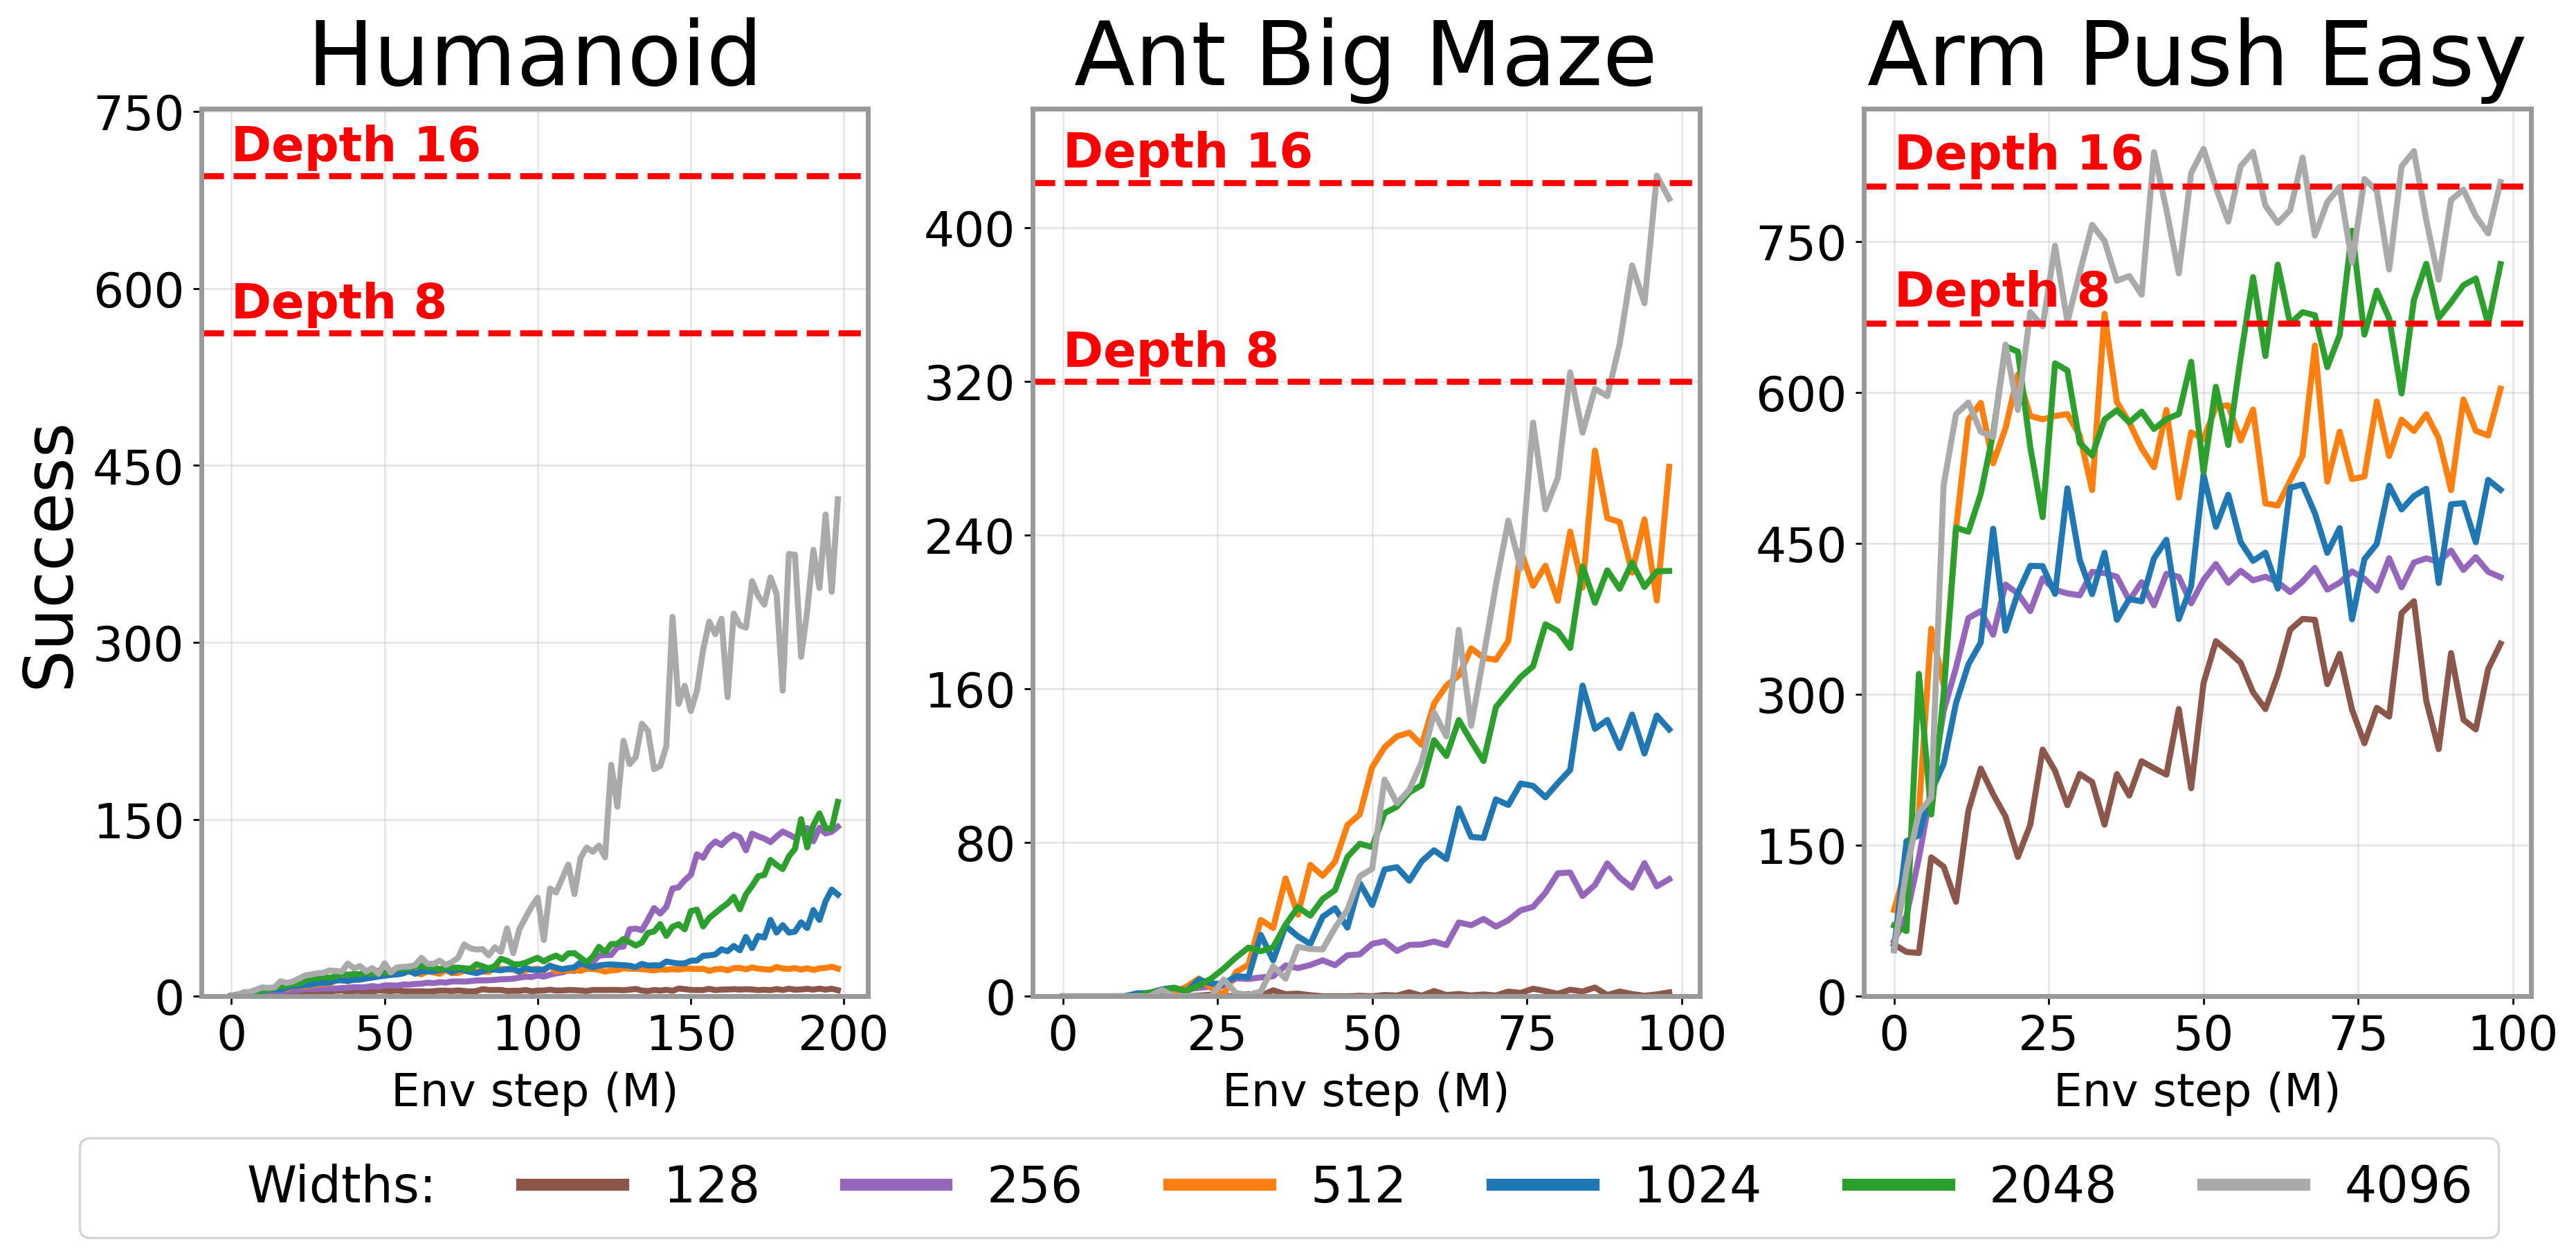

In [13]:
# rc_params = {
#     'figure.dpi': 250,
#     'axes.titlesize': 37,
#     'axes.labelsize': 28,
#     'xtick.labelsize': 20,
#     'ytick.labelsize': 20,
#     'legend.fontsize': 21,
# }

# horiz = [562.1331250000001, 695.7081249999999, 319.8830729166667, 423.5427083333333, 668.74125, 804.8309895833]
# facts = [1.03, 1.03, 1]
# # Specify environments
# env_list = ["humanoid", "ant_big_maze", "arm_push_easy"]

# colors = ["brown", "purple", "orange", "blue", "green", "red"]
# colors = ['#8c564b', '#9467bd', '#ff7f0e', '#1f77b4', '#2ca02c', '#aaaaaa']

# # 92c6e2
# # Call the function with the specified rcParams and figure size
# plot_envs_subplots(allData, env_list, nrows=1, ncols=3, rc_params=rc_params, 
#                    figsize=(15, 7), colors = colors, average_every = 2, 
#                    linewidth=2.5, horiz = horiz, padding=6, facts = facts,
#                   depSize=20.2)


In [21]:
mpl.rcdefaults()

In [27]:
env_data['width_std']

{128: [23.801324740173747,
  19.07254814098871,
  6.905339660024878,
  6.841810535152649,
  37.28330989240632,
  24.127256772126923,
  11.824703633826601,
  18.166567577593447,
  1.3037281278126969,
  16.086679271993955,
  36.94909145286112,
  17.299256916294322,
  14.180805525827088,
  0.7043446453225375,
  4.847548441337464,
  57.30879490647847,
  12.38817935008463,
  6.593218307391753,
  2.4223931527367273,
  57.90817838896862,
  36.26408175858665,
  34.057135203242694,
  37.17558659370993,
  10.985014331167575,
  3.7979368130136826,
  21.38721799502905,
  21.93135876023901,
  25.91435867614136,
  4.306169811991514,
  12.645057985437557,
  62.454654021129,
  26.071800420389927,
  12.96546574566271,
  25.348120824019322,
  15.545300642648005,
  36.53200893739562,
  41.29669330281278,
  2.762135864009951,
  9.308397861713535,
  3.6266843894450655,
  1.4832669589733438,
  30.946970220367493,
  11.451815292185257,
  0.28449999399302495,
  0.9253155144433336,
  13.131193897503307,
  5.90

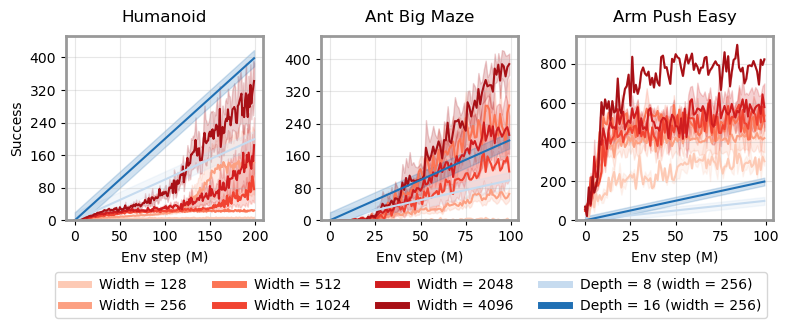

In [45]:
rc_params = {
    'figure.dpi': 250,
    'axes.titlesize': 37,
    'axes.labelsize': 28,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 21,
}

horiz = [562.1331250000001, 695.7081249999999, 319.8830729166667, 423.5427083333333, 668.74125, 804.8309895833]
facts = [1.03, 1.03, 1]
# Specify environments
env_list = ["humanoid", "ant_big_maze", "arm_push_easy"]

colors = ["brown", "purple", "orange", "blue", "green", "red"]
colors = ['#8c564b', '#9467bd', '#ff7f0e', '#1f77b4', '#2ca02c', '#aaaaaa']

values = np.linspace(0.2, 1, 7)
colors = [plt.cm.Reds(v) for v in values]

# 92c6e2
# Call the function with the specified rcParams and figure size
# plot_envs_subplots(allData, env_list, nrows=1, ncols=3, rc_params=rc_params, 
#                    figsize=(15, 7), colors = colors, average_every = 2, 
#                    linewidth=2.5, horiz = horiz, padding=6, facts = facts,
#                   depSize=20.2)
average_every = 1

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 3))
axs = axs.flatten()  # Flatten the axes array for easier indexing

def downsample_curve(curve, step):
    # Average every `step` points in the curve
    return [np.mean(curve[i:i + step]) for i in range(0, len(curve), step)]

for i, env_id in enumerate(env_list):
    if env_id not in allData:
        print(f"Warning: {env_id} not found in allData")
        continue

    env_data = allData[env_id]
    env_title = env_data["env_title"]
    num_epochs = len(env_data["width_mean"][list(env_data["width_mean"].keys())[0]]) // average_every
    width_mean = env_data["width_mean"]
    
    ax = axs[i]
    for j, (width, mean_curve) in enumerate(width_mean.items()):
        # Downsample mean_curve based on average_every
        downsampled_mean = downsample_curve(mean_curve, average_every)
        
        color = colors[j % len(colors)] if colors else None  # Use provided color or default
        ax.plot(np.array(range(num_epochs)) * average_every, downsampled_mean, label=f"Width = {width}", color=color)
        ax.fill_between(np.array(range(num_epochs)) * average_every, np.array(mean_curve) - np.array(env_data['width_std'][width]),
                        np.array(mean_curve) + np.array(env_data['width_std'][width]),
                    color=color, alpha=0.2)

    for depth in [8, 16]:
        y_fake = depth / 8 * np.arange(len(downsampled_mean))
        y_err = np.ones_like(downsampled_mean) * 20
        color = plt.cm.Blues(0.25 if depth == 8 else 0.75)
        ax.plot(np.array(range(num_epochs)) * average_every, y_fake, color=color, label='Depth = %s (width = 256)' % depth)
        ax.fill_between(np.array(range(num_epochs)) * average_every, y_fake - y_err, y_fake + y_err,
                    color=color, alpha=0.2)
    
    # Draw horizontal lines and add text if `horiz` is provided
    # padding = 6
    # depSize = 20.2
    # if horiz:
    #     line1, line2 = horiz[2 * i], horiz[2 * i + 1]
    #     ax.axhline(y=line1, color='red', linestyle='--', linewidth=2.5)
    #     ax.axhline(y=line2, color='red', linestyle='--', linewidth=2.5)
        # ax.text(0, line1 + padding / 100 * ax.get_ylim()[1], "Depth 8", color='red', weight='bold', fontsize=depSize, va='top', ha='left')
        # ax.text(0, line2 + padding / 100 * ax.get_ylim()[1], "Depth 16", color='red', weight='bold', fontsize=depSize, va='top', ha='left')

    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.set_title(f"{env_title}", pad=10)
    ax.set_xlabel("Env step (M)", labelpad=5)
    if i % 3 == 0:
        ax.set_ylabel("Success")
    ax.grid(True, alpha=0.3)

    ax.set_ylim(0, ax.get_ylim()[1] * facts[i])

# Create legend from the first subplot
handles, labels = axs[0].get_legend_handles_labels()
legend_handles = [mpl.lines.Line2D([], [], color=h.get_color(), linewidth=5) for h in handles]

# Add "Widths:" label manually
# legend_handles.insert(0, mpl.lines.Line2D([], [], color='none'))
# labels.insert(0, "Widths:")

# Adjust layout and add legend
for ax in axs:
    ax.spines['top'].set_color('#000000')  # Set top border to black
    ax.spines['bottom'].set_color('#000000')  # Set bottom border to black
    ax.spines['left'].set_color('#000000')  # Set left border to black
    ax.spines['right'].set_color('#000000')  # Set right border to black
    ax.spines['top'].set_linewidth(2)  # Optional: Make borders thicker
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
for ax in axs:
    ax.spines['top'].set_color('#999999')
    ax.spines['bottom'].set_color('#999999')
    ax.spines['left'].set_color('#999999')
    ax.spines['right'].set_color('#999999')


leg = fig.legend(legend_handles, labels, loc='lower center', bbox_to_anchor=(0.52, -0.1),
           ncol=4)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust bottom margin to make room
plt.savefig("scaling-width.pdf", bbox_inches="tight", bbox_extra_artists=(leg,))
plt.show()


In [29]:
env_data['width_std']

{128: [0.07733980419227864,
  0.22373300498480603,
  0.17125242356861697,
  0.25687863535292543,
  0.4888980479297613,
  0.24030582016886573,
  0.2872621298570349,
  0.30935921676911454,
  0.41984465132951254,
  0.38117474923337324,
  0.38117474923337324,
  0.4916601837937713,
  0.1629660159765871,
  0.01933495104806966,
  0.035907766232129365,
  0.1298203856084677,
  0.3563155264572837,
  0.09667475524034828,
  0.3507912547292638,
  0.11877184215242789,
  0.22373300498480603,
  0.27345145053698516,
  0.18782523875267668,
  0.27897572226500505,
  0.2651650429449553,
  0.14915533665653735,
  0.25135436362490554,
  0.15467960838455727,
  0.16020388011257716,
  0.1077232986963881,
  0.2983106733130747,
  0.5386164934819404,
  0.5689999879860499,
  0.8894077482112043,
  0.5579514445300101,
  0.08010194005628858,
  0.9998931827716023,
  0.1463932007925274,
  0.24030582016886573,
  1.1186650249240302,
  0.37841261336936327,
  0.5551893086660001,
  0.5137572707058509,
  0.1077232986963881,
  